In [1]:
%matplotlib inline

import json
import os
#from typing import Any, Hashable, Tuple

import pandas as pd
#from sklearn.metrics import (
#    ConfusionMatrixDisplay,
#    confusion_matrix,
#    precision_recall_fscore_support,
#)

import matplotlib.pyplot as plt

from kibad_llm.config import PROJ_ROOT
#from kibad_llm.dataset.json import read_and_preprocess
#from kibad_llm.dataset.utils import merge_references_into_predictions
#from kibad_llm.utils.dictionary import flatten_dict_simple

# swith to project root to use same paths as in commands
os.chdir(PROJ_ROOT)
# set wider column width for displaying pandas data frames
pd.set_option("max_colwidth", 400)

2025-12-02 10:27:47.341 | INFO     | kibad_llm.config:<module>:11 - PROJ_ROOT path is: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm


In [6]:
metrics_file = "data/prediction_results/2025-11-25_19-49-41/job_return_value_micro_f1.json"
with open(metrics_file, 'rb') as fin:
    metrics = json.load(fin)
f"loaded {len(metrics)} metrics"

'loaded 31 metrics'

In [9]:
metrics_df = pd.DataFrame.from_dict(metrics).T
metrics_df.head()

,precision,recall,f1,support
biodiversity_level,0.295775,0.313433,0.304348,67.0
biodiversity_variable,0.007092,0.014706,0.009569,68.0
climate,0.163934,0.500000,0.246914,20.0
conservation_area,0.000000,0.000000,0.000000,2.0
direct_driver,0.355556,0.340426,0.347826,94.0


<Axes: >

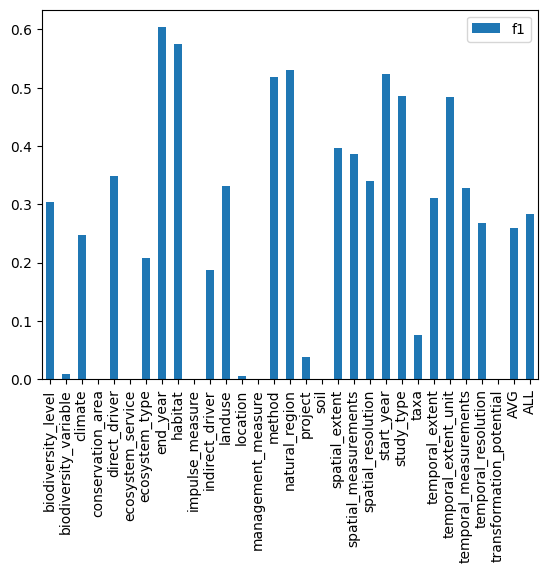

In [14]:
#fig, ax = plt.subplots()
#
#labels = metrics_df.index.to_list()
#f1 = metrics_df['f1']
metrics_df.plot.bar(y='f1') #y=['precision','recall','f1'])

In [26]:
# load metrics for several runs. Expects the metrics file to be named 'job_return_value.json'
# specified as a dict to manually add a descriptive label per run
run_folders = {'2025-11-25_19-49-41': "two_schemata, issue #109"}
metrics_dict = {}
for folder in run_folders.keys():
    metrics_file = f"data/prediction_results/{folder}/job_return_value.json"
    with open(metrics_file, 'rb') as fin:
        metrics_dict[folder] = json.load(fin)
f"loaded metrics for {len(metrics_dict)} run(s)"

'loaded metrics for 1 run(s)'

In [35]:
run_metrics_df = pd.DataFrame.from_dict({k: v["ALL"] for k, v in sorted(metrics_dict.items())}).T
run_metrics_df['run'] = [run_folders[k] for k, _ in sorted(metrics_dict.items())]
run_metrics_df.head()

,precision,recall,f1,support,desc,run
2025-11-25_19-49-41,0.24257,0.339597,0.282998,1490,"two_schemata, issue #109","two_schemata, issue #109"


<Axes: xlabel='run'>

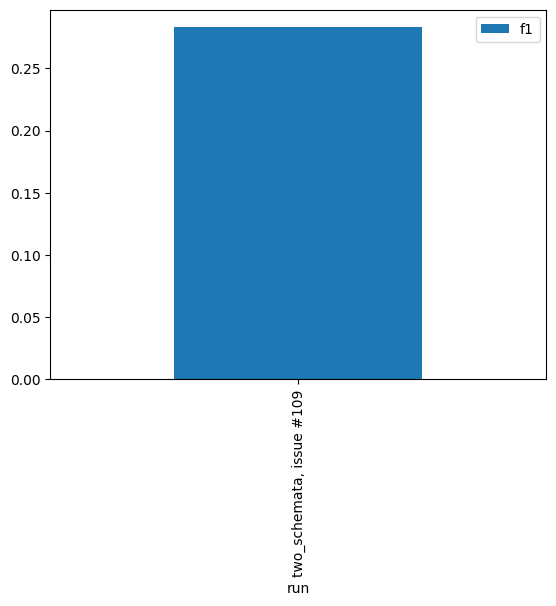

In [36]:
run_metrics_df.plot.bar(x='run', y='f1') #y=['precision','recall','f1'])